## Session 23 - Medical Cost Personal Datasets
#### Link of Dataset : https://www.kaggle.com/datasets/mirichoi0218/insurance

In [42]:
'''
Import Required Libraries
'''

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [43]:
'''
Load Dataset
'''

# Load Dataset
df = pd.read_csv("insurance.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         

In [44]:
'''
Data Cleaning & Preprocessing
'''

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

# Separate Features and Target
X = df.drop("charges", axis=1)
y = df["charges"]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Dataset Shape: (1337, 7)

Shape of X: (1337, 6)
Shape of y: (1337,)


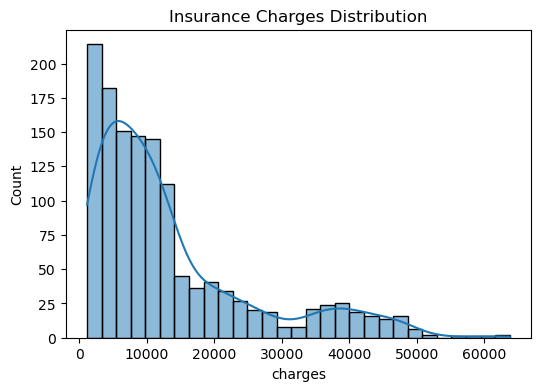

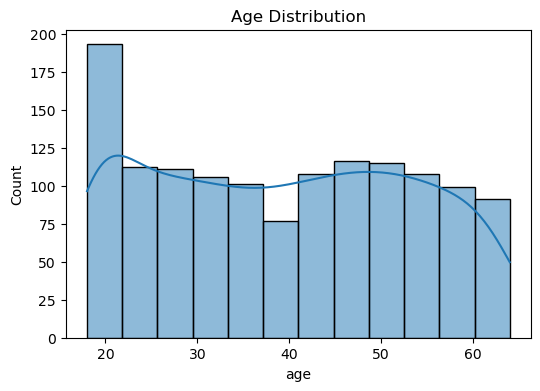

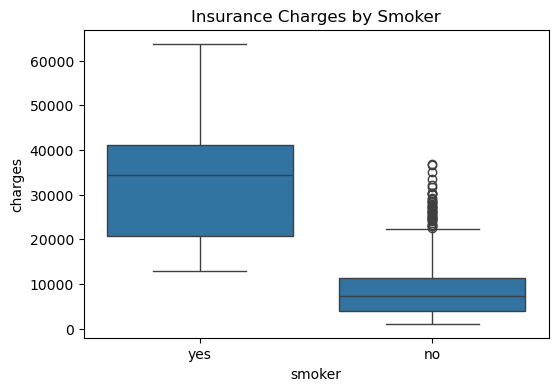

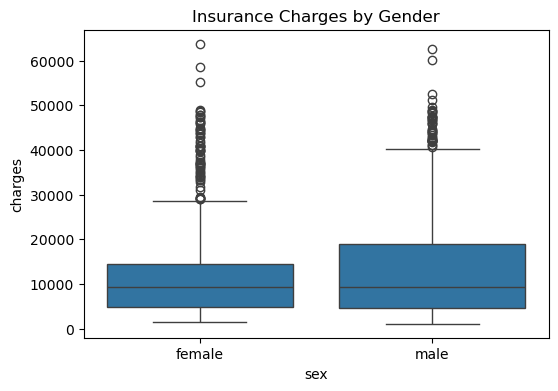

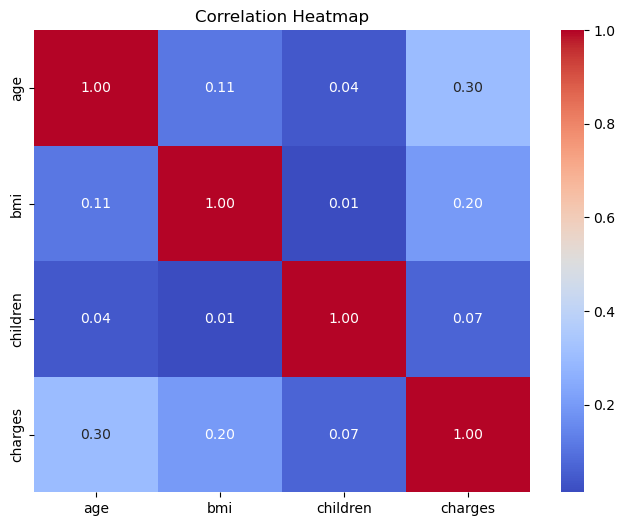

In [45]:
'''
Exploratory Data Analysis
'''

# Charges Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

# Charges by Smoker
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Insurance Charges by Smoker")
plt.show()

# Charges by Gender
plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Insurance Charges by Gender")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [46]:
'''
Encoding & Feature Scaling
'''

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Save Column Names
columns = X.columns

# Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Encoding and Scaling Completed Successfully.")

Encoding and Scaling Completed Successfully.


In [47]:
'''
Train-Test Split
'''

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


In [48]:
'''
Linear Regression Model Training
'''

from sklearn.linear_model import LinearRegression

# Create Model
lr_model = LinearRegression()

# Train Model
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


In [49]:
'''
Model Prediction
'''

y_pred_lr = lr_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_lr[:10])

First 10 Actual Values:
[ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051   9304.7019
 38511.6283   2150.469    7345.7266  10264.4421 ]

First 10 Predicted Values:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706 13149.72235307 30446.76067941  1453.28881259
 10633.01840233 11318.94379361]


In [50]:
'''
Model Evaluation
'''

from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred_lr)

print("R² Score :", round(r2_lr,4))

R² Score : 0.8069


In [51]:
'''
Decision Tree Regressor Model Training
'''

from sklearn.tree import DecisionTreeRegressor

# Create Model
dt_model = DecisionTreeRegressor(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

print("Decision Tree Regressor Trained Successfully.")

Decision Tree Regressor Trained Successfully.


In [52]:
'''
Model Prediction
'''

y_pred_dt = dt_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_dt[:10])

First 10 Actual Values:
[ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051   9304.7019
 38511.6283   2150.469    7345.7266  10264.4421 ]

First 10 Predicted Values:
[ 9361.3268   4877.98105 10848.1343  44585.45587  4673.3922   8978.1851
 36219.40545  2154.361   19144.57652 10269.46   ]


In [53]:
'''
Model Evaluation
'''

r2_dt = r2_score(y_test, y_pred_dt)

print("R² Score :", round(r2_dt,4))

R² Score : 0.8137


In [54]:
'''
Support Vector Regressor (SVR) Model Training
'''

from sklearn.svm import SVR

# Create Model
svr_model = SVR(kernel="rbf")

# Train Model
svr_model.fit(X_train, y_train)

print("SVR Model Trained Successfully.")

SVR Model Trained Successfully.


In [55]:
'''
Model Prediction
'''

y_pred_svr = svr_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_svr[:10])

First 10 Actual Values:
[ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051   9304.7019
 38511.6283   2150.469    7345.7266  10264.4421 ]

First 10 Predicted Values:
[9286.5177216  9275.79595528 9306.19330745 9320.65864281 9257.12710605
 9291.3572724  9320.54206512 9239.86823456 9274.8216007  9290.72032035]


In [56]:
'''
Model Evaluation
'''

r2_svr = r2_score(y_test, y_pred_svr)

print("R² Score :", round(r2_svr,4))

R² Score : -0.1312


In [57]:
'''
K-Nearest Neighbors Regressor Model Training
'''

from sklearn.neighbors import KNeighborsRegressor

scores = {}

for k in [3,5,7]:

    knr = KNeighborsRegressor(n_neighbors=k)

    knr.fit(X_train, y_train)

    pred = knr.predict(X_test)

    scores[k] = r2_score(y_test, pred)

    print(f"K = {k} --> R² Score = {scores[k]:.4f}")

K = 3 --> R² Score = 0.8501
K = 5 --> R² Score = 0.8371
K = 7 --> R² Score = 0.8287


In [58]:
'''
Select Best K Value
'''

best_k = max(scores, key=scores.get)

print("Best K Value :", best_k)

Best K Value : 3


In [59]:
'''
Final KNN Regressor Model Training
'''

knn_model = KNeighborsRegressor(n_neighbors=best_k)

knn_model.fit(X_train, y_train)

print("Final KNN Regressor Trained Successfully.")

Final KNN Regressor Trained Successfully.


In [60]:
'''
Model Prediction
'''

y_pred_knn = knn_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_knn[:10])

First 10 Actual Values:
[ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051   9304.7019
 38511.6283   2150.469    7345.7266  10264.4421 ]

First 10 Predicted Values:
[ 8873.87071667  9798.03057667 11152.81133333 31417.99958
  4618.56566667  8162.45386667 48038.82379333  2067.60766667
  7551.88813333 10163.44633333]


In [61]:
'''
Model Evaluation
'''

r2_knn = r2_score(y_test, y_pred_knn)

print("R² Score :", round(r2_knn,4))

R² Score : 0.8501


In [62]:
'''
Performance Comparison of Models
'''

comparison = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Support Vector Regressor",
        f"KNN Regressor (K={best_k})"
    ],
    "R² Score": [
        r2_lr,
        r2_dt,
        r2_svr,
        r2_knn
    ]
})

comparison = comparison.round(4)

print("Model Performance Comparison:\n")
print(comparison)

Model Performance Comparison:

                  Algorithm  R² Score
0         Linear Regression    0.8069
1   Decision Tree Regressor    0.8137
2  Support Vector Regressor   -0.1312
3       KNN Regressor (K=3)    0.8501


In [63]:
'''
Best Performing Algorithm
'''

best_algorithm = comparison.loc[
    comparison["R² Score"].idxmax(),
    "Algorithm"
]

print("Best Performing Algorithm:", best_algorithm)

print("\nConclusion:")
print(f"{best_algorithm} achieved the highest R² Score and performed best on the Medical Insurance dataset.")

Best Performing Algorithm: KNN Regressor (K=3)

Conclusion:
KNN Regressor (K=3) achieved the highest R² Score and performed best on the Medical Insurance dataset.


In [64]:
'''
Best Regression Model
'''

best_regression_model = comparison.loc[
    comparison["R² Score"].idxmax(),
    "Algorithm"
]

print("Best Regression Model:", best_regression_model)

Best Regression Model: KNN Regressor (K=3)


In [65]:
'''
Save Best Regression Model
'''

if best_regression_model == "Linear Regression":
    best_reg_model = lr_model

elif best_regression_model == "Decision Tree Regressor":
    best_reg_model = dt_model

elif best_regression_model == "Support Vector Regressor":
    best_reg_model = svr_model

else:
    best_reg_model = knn_model

joblib.dump(best_reg_model, "best_regression_model.pkl")
joblib.dump(scaler, "regression_scaler.pkl")
joblib.dump(columns, "regression_columns.pkl")

print("Best Regression Model Saved Successfully.")

Best Regression Model Saved Successfully.


In [66]:
import joblib
import os

# Save Models
joblib.dump(lr_model, "linear_regression.pkl")
joblib.dump(dt_model, "decision_tree_regressor.pkl")
joblib.dump(svr_model, "svr_model.pkl")
joblib.dump(knn_model, "knn_regressor.pkl")

# Save Best Model
joblib.dump(best_reg_model, "best_regression_model.pkl")

# Save Scaler
joblib.dump(scaler, "insurance_scaler.pkl")

# Save Feature Columns
joblib.dump(columns.tolist(), "insurance_columns.pkl")

print("Regression models saved successfully!")

print("\nCurrent Directory:")
print(os.getcwd())

print("\nSaved Files:")
for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Regression models saved successfully!

Current Directory:
C:\Users\rathi_pu888d0\Desktop\ITR\Jupyter Lab

Saved Files:
best_regression_model.pkl
decision_tree_regressor.pkl
insurance_columns.pkl
insurance_scaler.pkl
knn_regressor.pkl
linear_regression.pkl
regression_columns.pkl
regression_scaler.pkl
svr_model.pkl
